In [92]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type = 'S2'
manifold = get_manifold(manifold_type)

In [93]:
n_samples = 5000
sigma2 = .1

# prior param
num_modes = 3
tau2 = 0.05
# G = G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 
G = lambda n: equator_sampler(manifold_type, n)

# get data
Theta =G(n_samples)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

Cross-validating:   0%|          | 0/5 [00:00<?, ?it/s]

Folds: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]


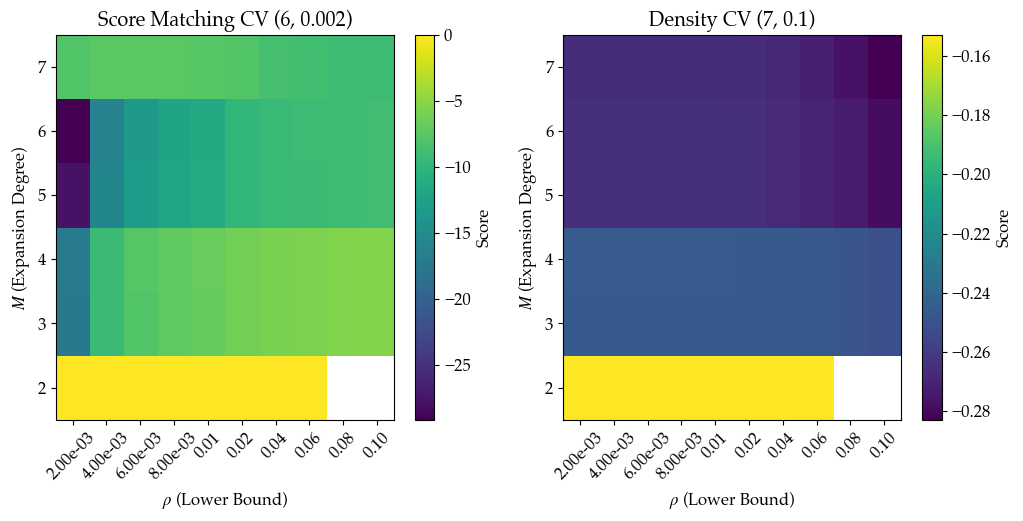

In [96]:
M_grid=np.arange(2, 8)
# rho_grid = 0.0001,0.0005, 0.001, [0.0025, 0.005, 0.0075, 0.001, 0.025, 0.05, 0.075, 0.1, 0.25] 
rho_grid = [0.002, 0.004, 0.006, 0.008, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1] 
fig, [axl,axr] = plt.subplots(1,2, figsize=(12,5))

Mrho, cv_scores = select_M_rho_by_DensityKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=5, return_scores=True, random_state=42)
plot_density_cv_scores(cv_scores, M_grid, rho_grid, ax=axr, title=f"Density CV {Mrho['cv']}")


Mrho, cv_scores =  select_M_rho_by_scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=5, return_scores=True, random_state=42)
plot_density_cv_scores(cv_scores, M_grid, rho_grid, ax=axl, title=f"Score Matching CV {Mrho['cv']}")

plt.show()



In [ ]:
# for empirical density estimation
M, rho = Mrho['cv']
# for oracle approximation
num_oracle_samples = 10000
oracle_bandwidth = 0.001



In [85]:
# --- denoisers
delta = denoiser(manifold_type, X, M, rho, sigma2, X)
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, X, G )
oracle_delta_B = oracle_bayes__kernel(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, X, G )
# --- losses
loss_N = sq_loss(manifold, X, Theta)
loss_T = sq_loss(manifold, delta, Theta) 
loss_oracle_T = sq_loss(manifold, oracle_delta_T, Theta) 
loss_oracle_B = sq_loss(manifold, oracle_delta_B, Theta) 

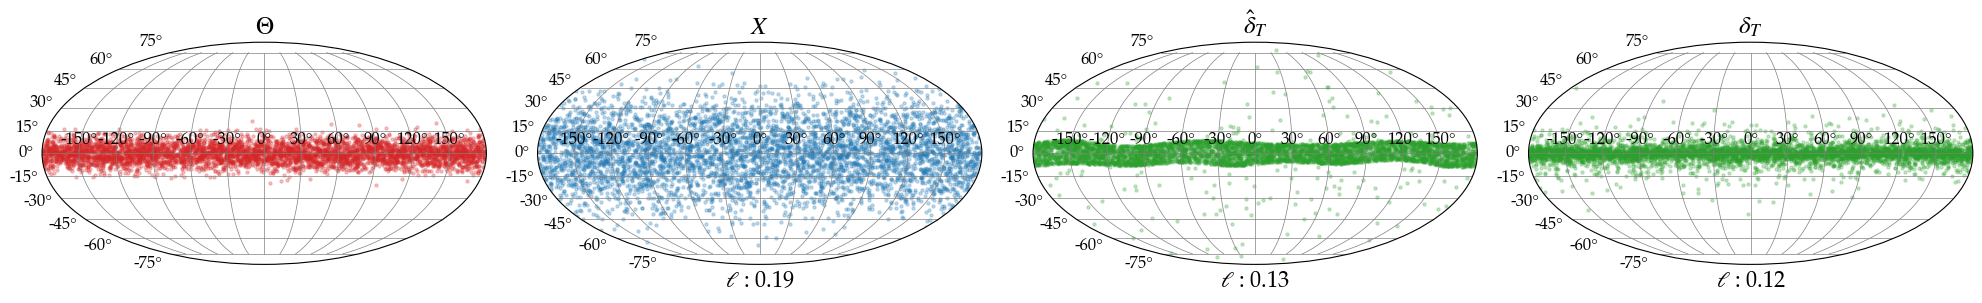

In [86]:
if True:
    fig, axs = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': 'mollweide'})

    S2scatter(Theta, axs[0], color='C3', alpha=0.25)
    axs[0].set_title(r'$\Theta$', fontsize=18)

    S2scatter(X, axs[1], color='C0', alpha=0.25)
    axs[1].set_title(r'$X$', fontsize=18)
    axs[1].set_xlabel(rf'$\ell$ : {loss_N:.2f}', fontsize=16)

    S2scatter(delta, axs[2], color='C2', alpha=0.25)
    axs[2].set_title(r'$\hat\delta_T$', fontsize=18)
    axs[2].set_xlabel(rf'$\ell$ : {loss_T:.2f}', fontsize=16)

    S2scatter(oracle_delta_T, axs[3], color='C2', alpha=0.25)
    axs[3].set_title(r'$\delta_T$', fontsize=18)
    axs[3].set_xlabel(rf'$\ell$ : {loss_oracle_T:.2f}', fontsize=16)

    plt.savefig('denoising_S2.png', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

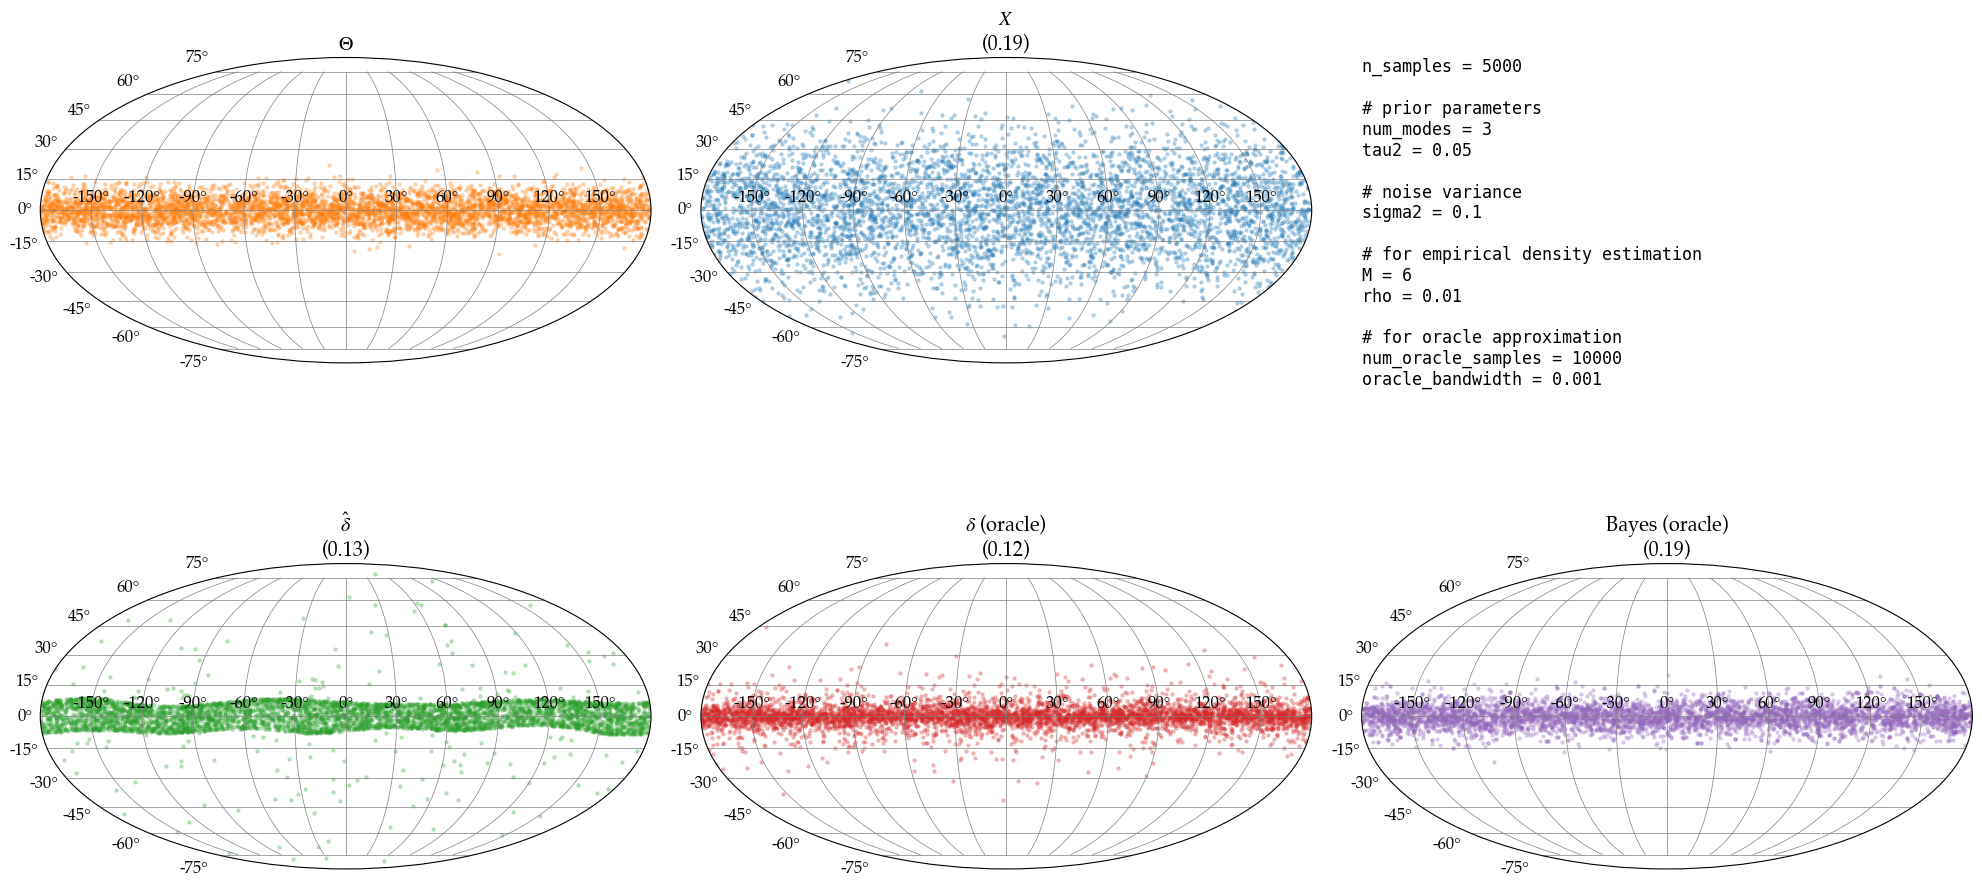

In [87]:
if True:
    # Single figure: 2 on top, 3 on bottom
    fig, axs = plt.subplots(2, 3, figsize=(20, 10), subplot_kw={'projection': 'mollweide'})

    # --- top row (use first two axes, use the third for a text panel) ---
    S2scatter(Theta, axs[0, 0], color='C1', alpha=0.25)
    axs[0, 0].set_title(r'$\Theta$')

    S2scatter(X, axs[0, 1], color='C0', alpha=0.25)
    axs[0, 1].set_title(rf'$X$' + '\n' + f'({loss_N:.2f})')

    # --- top-right: info panel ---
    axs[0, 2].set_axis_off()
    info = (
        f"n_samples = {n_samples}\n\n"
        f"# prior parameters\n"
        f"num_modes = {num_modes}\n"
        f"tau2 = {tau2}\n\n"
        f"# noise variance\n"
        f"sigma2 = {sigma2}\n\n"
        f"# for empirical density estimation\n"
        f"M = {M}\n"
        f"rho = {rho}\n\n"
        f"# for oracle approximation\n"
        f"num_oracle_samples = {num_oracle_samples}\n"
        f"oracle_bandwidth = {oracle_bandwidth}"
    )
    axs[0, 2].text(
        0.0, 1.0, info,
        transform=axs[0, 2].transAxes,
        va="top", ha="left",
        fontsize=12, family="monospace"
    )

    # --- bottom row (three denoisers) ---
    S2scatter(delta, axs[1, 0], color='C2', alpha=0.25)
    axs[1, 0].set_title(rf'$\hat\delta$' + '\n' + f'({loss_T:.2f})')
    S2scatter(oracle_delta_T, axs[1, 1], color='C3', alpha=0.25)
    axs[1, 1].set_title(rf'$\delta$ (oracle)' + '\n' + f'({loss_oracle_T:.2f})')

    S2scatter(oracle_delta_B, axs[1, 2], color='C4', alpha=0.25)
    axs[1, 2].set_title(rf'Bayes (oracle)' + '\n' + f'({loss_oracle_B:.2f})')

    plt.savefig('denoising_S2.png', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [88]:
grid_resolution = 50
grid, grid_theta, grid_phi = S2grid(grid_resolution)
_, hat_f, grad_hat_f, = density_estimate('S2', X, M, grid)
# _, hat_f, grad_hat_f, = kernel_density_estimate('S2', X, M, grid)


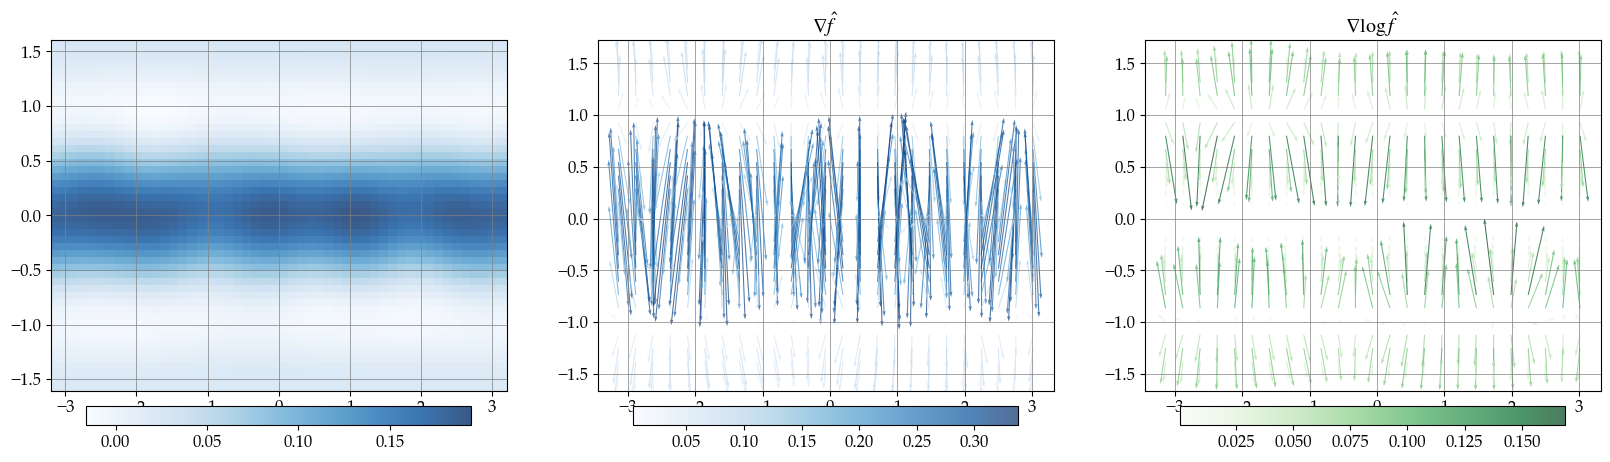

In [89]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), 
                        # subplot_kw={'projection': 'mollweide'}
                        )
skip = 2
S2plot_quiver(fig, {'f' : hat_f, 'grad_f' : grad_hat_f}, rho, 'gradient', axs[1], skip = skip, grid_resolution = grid_resolution, scale =1)
S2plot_quiver(fig, {'f' : hat_f, 'grad_f' : grad_hat_f}, rho, 'score', axs[2], skip = skip, grid_resolution = grid_resolution, scale =1)
im = axs[0].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Blues')
fig.colorbar(im, ax= axs[0], orientation='horizontal', fraction=0.05, pad=0.04)
axs[0].grid(True, color='gray', lw=0.5)


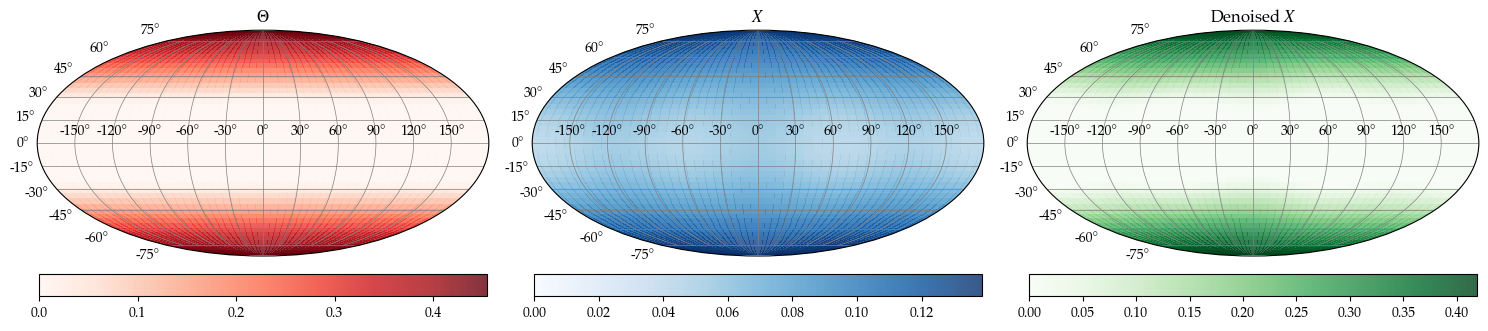

In [ ]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'mollweide'})

# grid_resolution = 50
# grid, grid_theta, grid_phi = S2grid(grid_resolution)

# densities = [density_estimate('S2', data, M, grid)[1].reshape(grid_resolution, grid_resolution) for data in [Theta, X, delta]]
# vmax = None #max([d.max() for d in densities])

# for hat_f, ax, title, cmap in zip(densities, axs, ['$\\Theta$', '$X$', 'Denoised $X$'], ['Reds', 'Blues', 'Greens']):
#     im = ax.pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f,
#                     alpha=0.8, shading='auto', cmap=cmap, vmin=0, vmax=vmax)
#     fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
#     ax.grid(True, color='gray', lw=0.5)
#     ax.set_title(title)
# plt.tight_layout(); plt.show()

# # fig = S2plot_density_gradient_score(X,M,sigma2,rho, grid_resolution =50, skip=2, mollwide=True); plt.show()

   

In [ ]:
n_samples = 1000000
G =lambda n: uniform_sampler(manifold_type, n ) 

Theta = multimodal_sampler(manifold_type, n_samples, tau2, num_modes)
sigma2s = np.logspace(-15,-1)
losses = np.zeros_like(sigma2s)
for ix, sigma2 in tqdm(enumerate(sigma2s), total=len(sigma2s)):
    X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
    naive_loss = sq_loss(manifold, X, Theta)
    losses[ix] = naive_loss

resid = losses - 2*sigma2s
mask = resid > 0  # needed for log
plt.show()

estimated p ≈ 1.4782, C ≈ 1.0000e+00, using 1 points


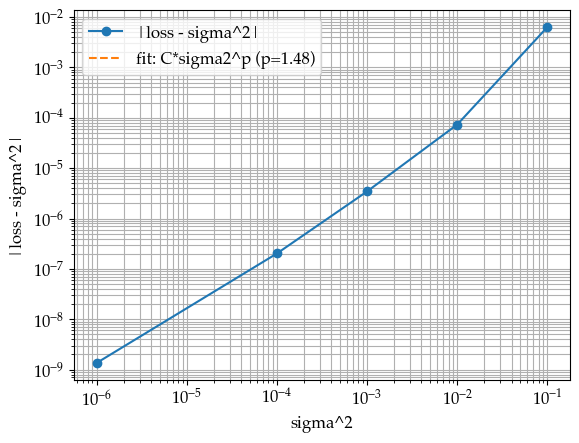

In [ ]:
sigma2_max = 1
mask = (sigma2s <= sigma2_max) & (resid > 0)

xs = np.log(sigma2s[mask])
ys = np.log(resid[mask])

# linear fit: ys ≈ a + p*xs
# p, a = np.polyfit(xs, ys, 1)  # slope=p, intercept=a
# C = np.exp(a)
p = np.dot(xs, ys) / np.dot(xs, xs)
a = 0.0
C = 1.0

print(f"estimated p ≈ {p:.4f}, C ≈ {C:.4e}, using {mask.sum()} points")

# plot
plt.figure()
plt.loglog(sigma2s, np.abs(resid), "o-", label="|loss - sigma^2|")
plt.loglog(
    sigma2s[mask],
    C * (sigma2s[mask] ** p),
    "--",
    label=f"fit: C*sigma2^p (p={p:.2f})",
)
plt.xlabel("sigma^2")
plt.ylabel("|loss - sigma^2|")
plt.legend()
plt.grid(True, which="both")
plt.show()